In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat


## DATASET OVERVIEW

In [2]:
df=pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [3]:
df.shape

(4600, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [6]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

**The number of unique countries is 1. Hence the dataset is only looking at the country USA.**

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4595    False
4596    False
4597    False
4598    False
4599    False
Length: 4600, dtype: bool

**No duplicate data available.**

## DATA CLEANING

In [8]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

**No null entries.**

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['date'] = pd.to_datetime(df['date'])

**Converting date to the date time format, as compared to it being object before.**

In [11]:
df['Year']=df['date'].dt.year
df['Month']=df['date'].dt.month

**Extracted year and month from date as new columns.**

In [12]:
df['country']=='USA'

0       True
1       True
2       True
3       True
4       True
        ... 
4595    True
4596    True
4597    True
4598    True
4599    True
Name: country, Length: 4600, dtype: bool

**There are 4600 entries overall in this dataset, and the number of entries with country as USA is 4600, hence the data focuses solely on the country USA**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  street         4600 non-null   object        
 15  city           4600 n

In [14]:
df['House_Age']=2026-df['yr_built']
df['House_Age']

0        71
1       105
2        60
3        63
4        50
       ... 
4595     72
4596     43
4597     17
4598     52
4599     36
Name: House_Age, Length: 4600, dtype: int64

**Calculating the total house age by subtracting the year it was built by the current year.**

In [15]:
df['renovated'] = (df['yr_renovated'] != 0).astype(int)
df['renovated']

0       1
1       0
2       0
3       0
4       1
       ..
4595    1
4596    1
4597    0
4598    0
4599    0
Name: renovated, Length: 4600, dtype: int64

**Assigning it and 0 based on it was ever renovated or not.**

In [16]:
df['Price_per_sqft']=df['price']/df['sqft_living']

**Tells you the price per square feet of the living area of the house.**

In [17]:
df['lot_utilization'] = df['sqft_living'] / df['sqft_lot']

**Tells you how much of the lot is occupied by the living area.**

In [18]:
columns = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 
           'yr_built', 'yr_renovated', 'House_Age', 'renovated', 'Price_per_sqft', 'lot_utilization']

negative_rows = df[(df[columns] < 0).any(axis=1)]

print(negative_rows)

Empty DataFrame
Columns: [date, price, bedrooms, bathrooms, sqft_living, sqft_lot, floors, waterfront, view, condition, sqft_above, sqft_basement, yr_built, yr_renovated, street, city, statezip, country, Year, Month, House_Age, renovated, Price_per_sqft, lot_utilization]
Index: []

[0 rows x 24 columns]


In [19]:
df['floors'].unique()

array([1.5, 2. , 1. , 2.5, 3. , 3.5])

In [20]:
df['waterfront'].unique()

array([0, 1])

In [21]:
df['view'].unique()

array([0, 4, 1, 2, 3])

In [22]:
df[df['yr_built'] > 2014]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,Year,Month,House_Age,renovated,Price_per_sqft,lot_utilization


In [23]:
df[df['yr_renovated'] > 2014]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,street,city,statezip,country,Year,Month,House_Age,renovated,Price_per_sqft,lot_utilization


## EDA

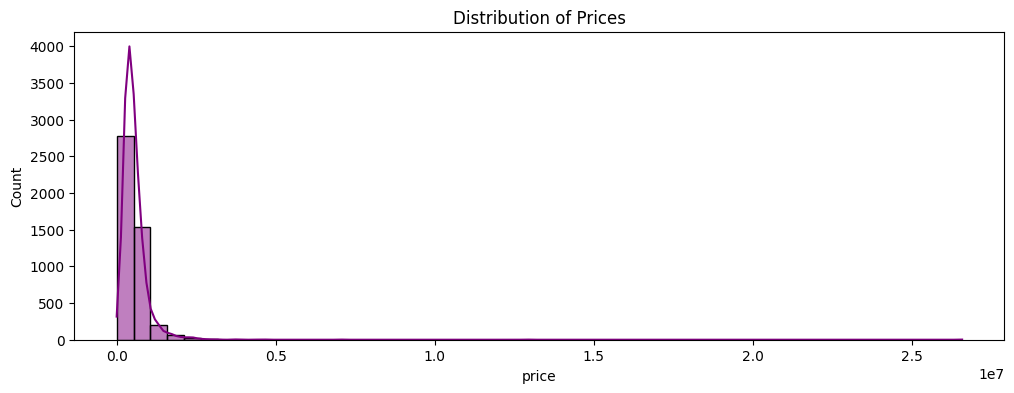

In [24]:
plt.figure(figsize=(12, 4))
sns.histplot(df['price'], kde=True, bins=50, color='purple')
plt.title("Distribution of Prices")
plt.show()

**The distribution of house prices is heavily right-skewed, showing a long tail extending toward multi-million dollar luxury properties, while the vast majority of homes are clustered in the lower-to-middle price tiers.**

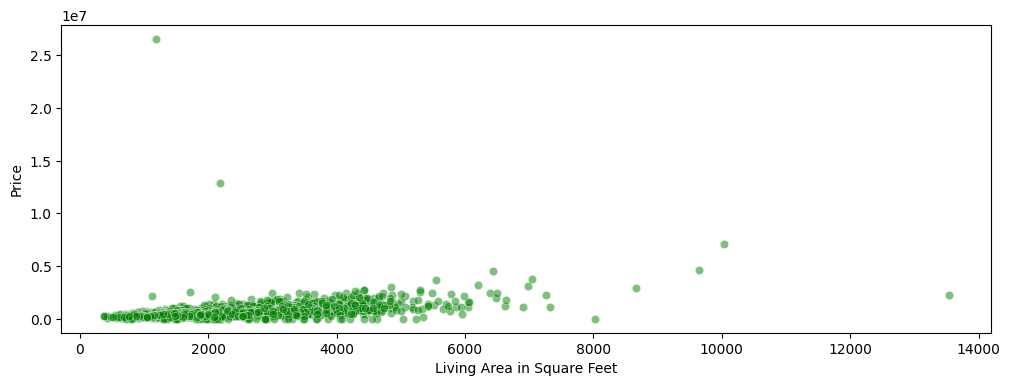

In [25]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df, x='sqft_living',y='price', alpha=0.5, color='green')
plt.xlabel('Living Area in Square Feet')
plt.ylabel('Price')
plt.show()

**There is a strong, positive linear correlation between sqft_living and price. As the internal living space increases, the market price of the home scales upward relatively predictably.**

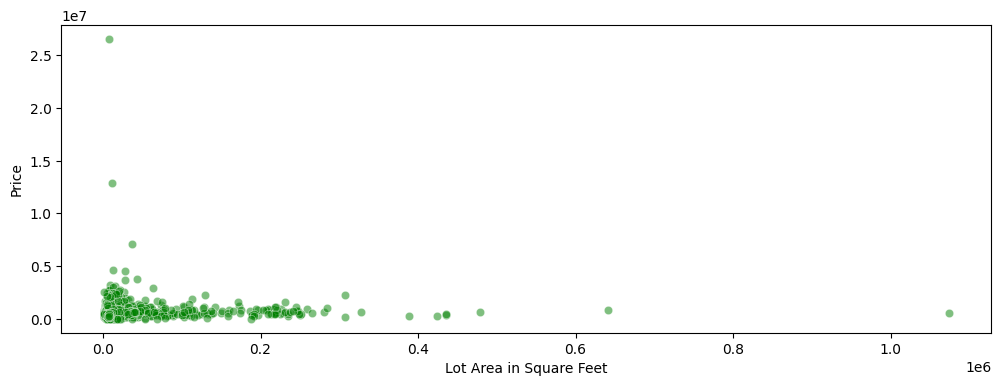

In [26]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df,x='sqft_lot',y='price', alpha=0.5, color='green')
plt.xlabel('Lot Area in Square Feet')
plt.ylabel('Price')
plt.show()

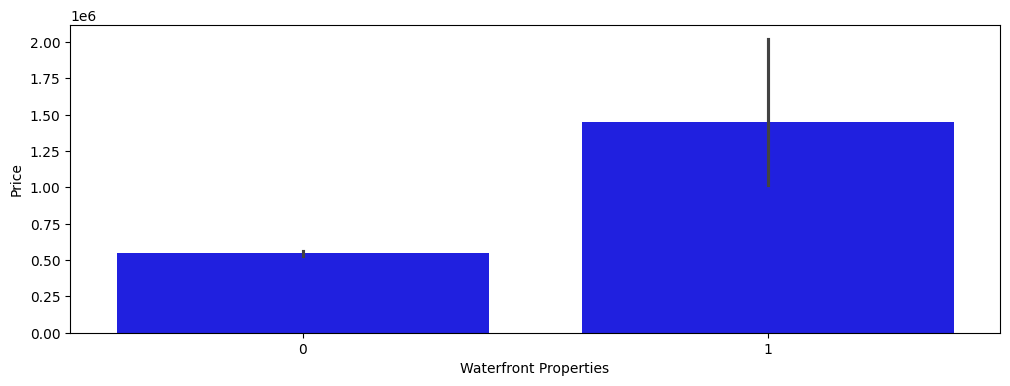

In [27]:
plt.figure(figsize=(12,4))
sns.barplot(data=df,x='waterfront',y='price', color='blue')
plt.xlabel('Waterfront Properties')
plt.ylabel('Price')
plt.show()

**Properties with a waterfront view (waterfront=1) command a significantly higher median price compared to those without one. The entire interquartile range (IQR) for waterfront homes sits well above the standard market average.**

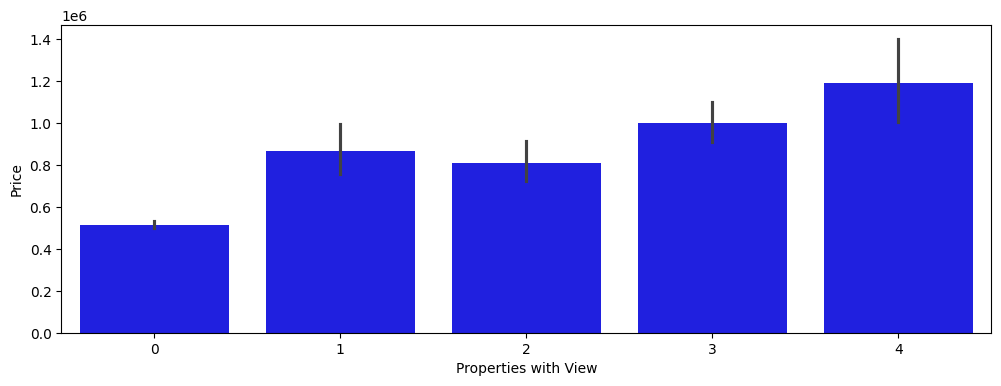

In [28]:
plt.figure(figsize=(12,4))
sns.barplot(data=df,x='view',y='price', color='blue')
plt.xlabel('Properties with View')
plt.ylabel('Price')
plt.show()

**Properties with a good view demand significantly higher prices than those with a less pleasant view or even no view at all. Hence it can also be a good measure to retain for our predictive model.**

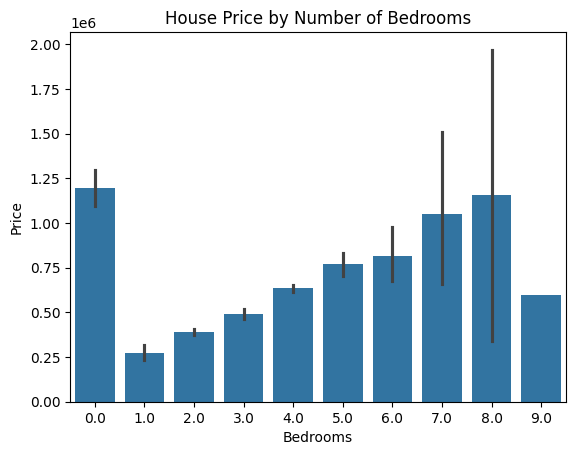

In [29]:
sns.barplot(data=df,x='bedrooms', y='price')
plt.suptitle('')
plt.title('House Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

**House prices generally increase with the number of bedrooms up to a certain point. However, two observations with zero bedrooms and zero bathrooms despite large living areas were identified as inconsistent records and were removed during data cleaning.**

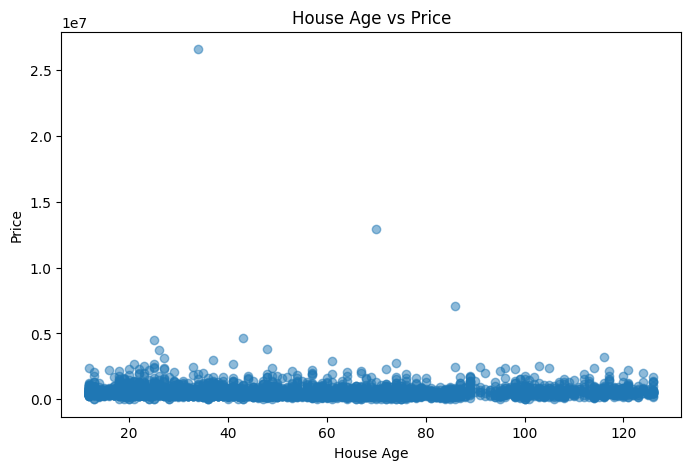

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(df["House_Age"], df["price"], alpha=0.5)

plt.xlabel("House Age")
plt.ylabel("Price")
plt.title("House Age vs Price")

plt.show()

**The scatter plot shows no strong linear relationship between house age and price. This suggests that house age alone may not be a strong predictor of selling price, although it could still contribute when combined with other variables.**

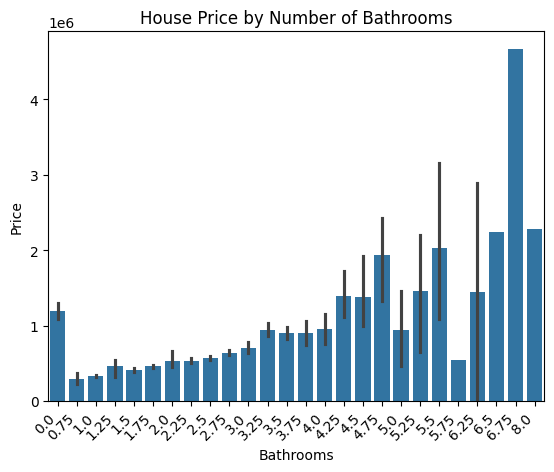

In [31]:
sns.barplot(data=df,y='price', x='bathrooms')
plt.title('House Price by Number of Bathrooms')
plt.suptitle('') 
plt.xticks(rotation=45, ha='right')
plt.xlabel('Bathrooms')
plt.ylabel('Price')
plt.show()

**Here we can see that more number of bathrooms also significantly changes the price at which it's being sold. Hence it can also be a relevant measure for our predictive model, hence we decide to keep it**

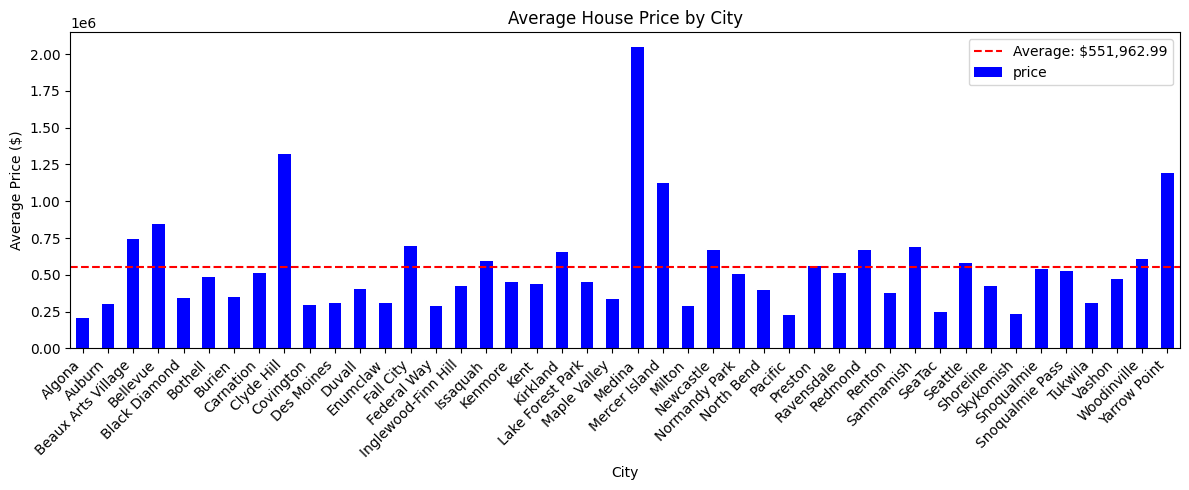

In [32]:
avg_price = df['price'].mean()
city_averages = df.groupby('city')['price'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
city_averages.plot(kind='bar', x='city', y='price', color='blue', legend=False, ax=ax)
ax.axhline(y=avg_price, color='red', linestyle='--', label=f'Average: ${avg_price:,.2f}')
ax.set_ylabel('Average Price ($)')
ax.set_xlabel('City')
ax.set_title('Average House Price by City')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

**The average prices of houses in Medina is much higher than the prices in other cities, hence our prediction model may end up learning trends and patterns more on the basis of Medina than the other cities.**

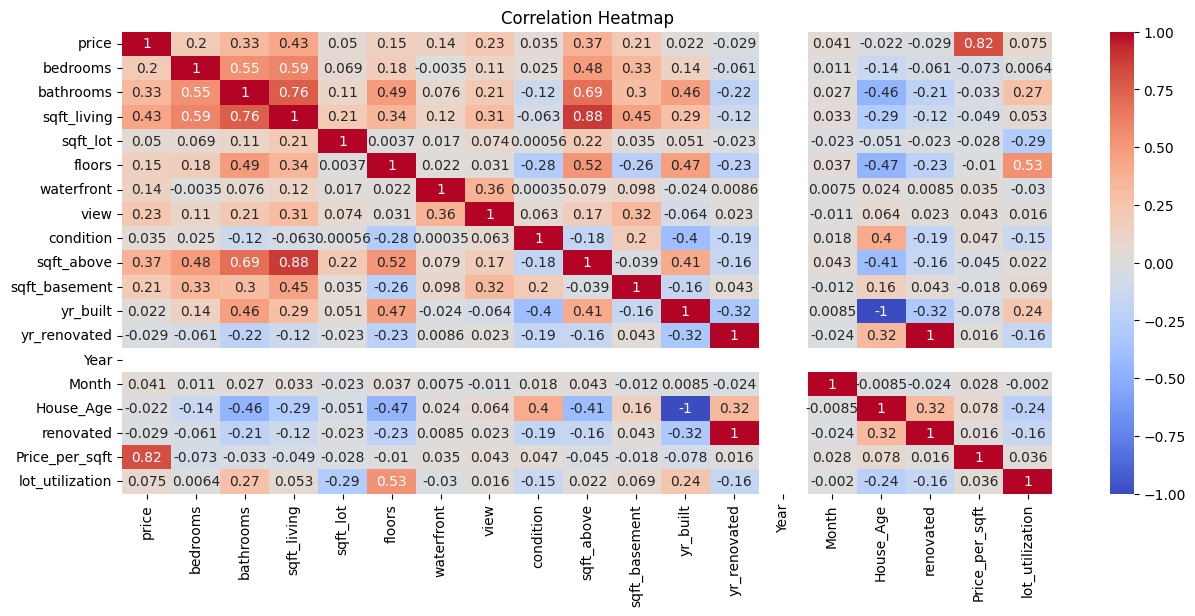

In [33]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [34]:
df['Year'].value_counts()

Year
2014    4600
Name: count, dtype: int64

**The entire dataset revolves around only one year, that is the year 2014, hence that column is dropped altogether due to it's lack of variance.**

In [35]:
df['Month'].value_counts()

Month
6    2179
5    1768
7     653
Name: count, dtype: int64

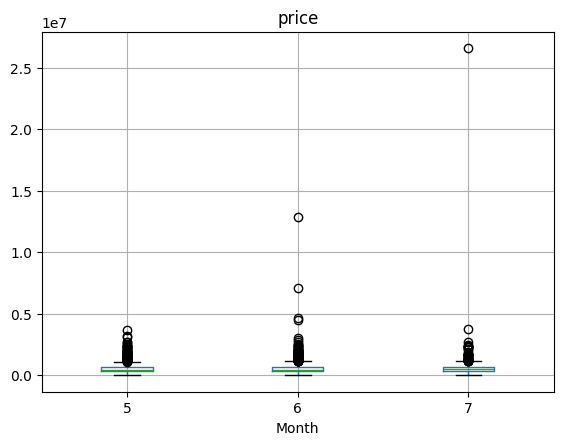

In [36]:
df.boxplot(column='price', by='Month')
plt.suptitle('')
plt.show()

In [37]:
df.drop(columns='Year', inplace=True)

**Drop year as year has no variance, it has only one consistent value across the dataset**

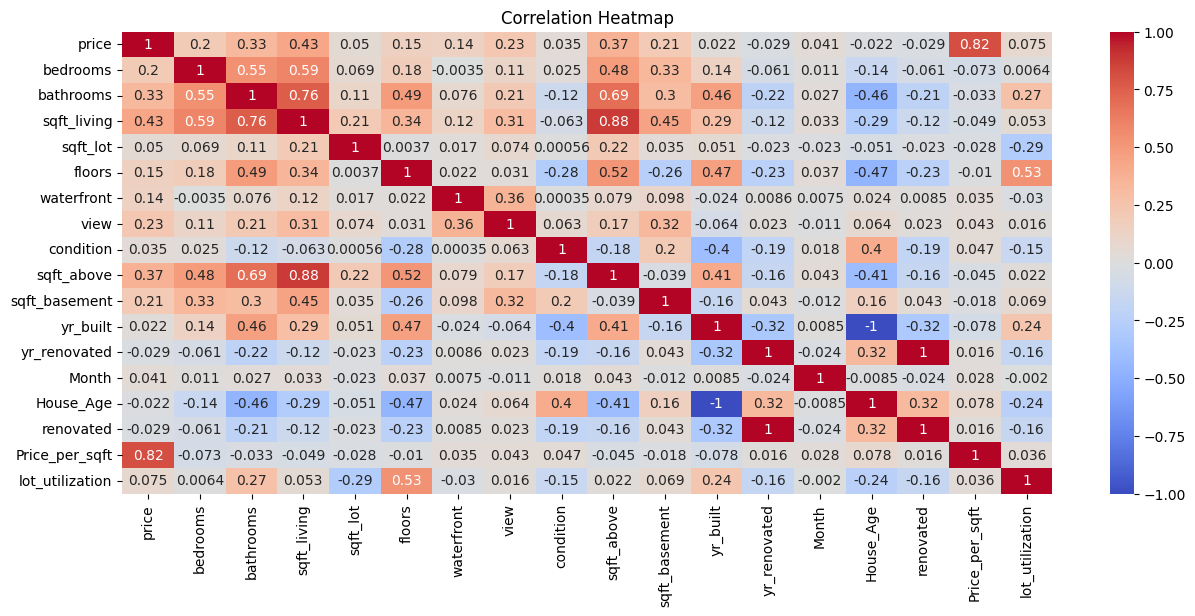

In [38]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Price and price per square feet have a high positive correlation but we can't well keep that or consider that for our predictions as price per square feet is derived using price itself. Price and sqft living has a decently strong positive correlation, hence we keep them. While the other factors don't have a high correlation with price, we still keep them as those factors combined with the others can still help us in predicting our target, which is price.**

In [39]:
columns = ['price', 'sqft_living', 'sqft_lot']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower<0:
        lower=0
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}")
    print(f"Normal range: {lower:.2f} to {upper:.2f}")
    print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

price
Normal range: 0.00 to 1153093.75
Outliers: 240 (5.22%)

sqft_living
Normal range: 0.00 to 4360.00
Outliers: 129 (2.80%)

sqft_lot
Normal range: 0.00 to 20002.00
Outliers: 541 (11.76%)



In [40]:
df.sort_values('price', ascending=False).head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
4350,2014-07-03,26590000.0,3.0,2.00,1180,7793,1.0,0,0,4,...,0,12005 SE 219th Ct,Kent,WA 98031,USA,7,34,0,22533.898305,0.151418
4346,2014-06-23,12899000.0,3.0,2.50,2190,11394,1.0,0,0,3,...,2001,5426 40th Ave W,Seattle,WA 98199,USA,6,70,1,5889.954338,0.192206
2286,2014-06-11,7062500.0,5.0,4.50,10040,37325,2.0,1,2,3,...,2001,4442 95th Ave NE,Bellevue,WA 98004,USA,6,86,1,703.436255,0.268989
2654,2014-06-17,4668000.0,5.0,6.75,9640,13068,1.0,1,4,3,...,2009,5044 Butterworth Rd,Mercer Island,WA 98040,USA,6,43,1,484.232365,0.737680
2761,2014-06-18,4489000.0,4.0,3.00,6430,27517,2.0,0,0,3,...,0,1149-1199 91st Ave NE,Bellevue,WA 98004,USA,6,25,0,698.133748,0.233674
3729,2014-07-01,3800000.0,5.0,5.50,7050,42840,1.0,0,2,4,...,2000,1365 91st Ave NE,Clyde Hill,WA 98004,USA,7,48,1,539.007092,0.164566
1637,2014-05-30,3710000.0,4.0,3.50,5550,28078,2.0,0,2,4,...,0,3222 78th Pl NE,Medina,WA 98039,USA,5,26,0,668.468468,0.197664
252,2014-05-07,3200000.0,7.0,4.50,6210,8856,2.5,0,2,5,...,0,1230 Warren Ave N,Seattle,WA 98109,USA,5,116,0,515.297907,0.701220
1567,2014-05-29,3100000.0,6.0,4.25,6980,15682,3.0,0,4,4,...,0,5243 Forest Ave SE,Mercer Island,WA 98040,USA,5,27,0,444.126074,0.445096
2772,2014-06-18,3000000.0,4.0,4.25,4850,12445,2.0,1,4,5,...,0,11031 Champagne Point Rd NE,Kirkland,WA 98034,USA,6,37,0,618.556701,0.389715


**An extremely priced luxurious house having 3 bedrooms and 2 bathrooms all the while not being waterfront and not having a good view seems atypical in this dataset. And since it can confuse our linear regression model, we get rid of it.**

In [41]:
df = df[df['price'] != df['price'].max()]
df.sort_values('price', ascending=False).head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
4346,2014-06-23,12899000.0,3.0,2.50,2190,11394,1.0,0,0,3,...,2001,5426 40th Ave W,Seattle,WA 98199,USA,6,70,1,5889.954338,0.192206
2286,2014-06-11,7062500.0,5.0,4.50,10040,37325,2.0,1,2,3,...,2001,4442 95th Ave NE,Bellevue,WA 98004,USA,6,86,1,703.436255,0.268989
2654,2014-06-17,4668000.0,5.0,6.75,9640,13068,1.0,1,4,3,...,2009,5044 Butterworth Rd,Mercer Island,WA 98040,USA,6,43,1,484.232365,0.737680
2761,2014-06-18,4489000.0,4.0,3.00,6430,27517,2.0,0,0,3,...,0,1149-1199 91st Ave NE,Bellevue,WA 98004,USA,6,25,0,698.133748,0.233674
3729,2014-07-01,3800000.0,5.0,5.50,7050,42840,1.0,0,2,4,...,2000,1365 91st Ave NE,Clyde Hill,WA 98004,USA,7,48,1,539.007092,0.164566
1637,2014-05-30,3710000.0,4.0,3.50,5550,28078,2.0,0,2,4,...,0,3222 78th Pl NE,Medina,WA 98039,USA,5,26,0,668.468468,0.197664
252,2014-05-07,3200000.0,7.0,4.50,6210,8856,2.5,0,2,5,...,0,1230 Warren Ave N,Seattle,WA 98109,USA,5,116,0,515.297907,0.701220
1567,2014-05-29,3100000.0,6.0,4.25,6980,15682,3.0,0,4,4,...,0,5243 Forest Ave SE,Mercer Island,WA 98040,USA,5,27,0,444.126074,0.445096
2772,2014-06-18,3000000.0,4.0,4.25,4850,12445,2.0,1,4,5,...,0,11031 Champagne Point Rd NE,Kirkland,WA 98034,USA,6,37,0,618.556701,0.389715
2328,2014-06-11,2888000.0,5.0,6.25,8670,64033,2.0,0,4,3,...,2003,1291 NW Elford Dr,Seattle,WA 98177,USA,6,61,1,333.102653,0.135399


**We remove the highest entry which stands at 26 million as despite having 3 bedrooms and 2 bathrooms, it is neither waterfront, nor does it have a good view, which does not justify it's high price. This was considered as a data error due to it being highly unusual from the rest of the dataset, and was hence promptly removed.**

In [42]:
df.sort_values('price', ascending=False).tail(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
4509,2014-06-18,0.0,6.0,3.00,3020,13783,2.0,0,0,3,...,2002,4115 85th Ave SE,Mercer Island,WA 98040,USA,6,74,1,0.0,0.219110
4528,2014-06-24,0.0,4.0,5.00,4550,18641,1.0,1,4,3,...,0,425 E Lake Sammamish Pkwy SE,Sammamish,WA 98074,USA,6,24,0,0.0,0.244086
4574,2014-07-02,0.0,3.0,1.00,1520,9030,1.0,0,0,3,...,2001,2533 155th Pl SE,Bellevue,WA 98007,USA,7,70,1,0.0,0.168328
4575,2014-07-02,0.0,5.0,6.25,8020,21738,2.0,0,0,3,...,0,2 Crescent Key,Bellevue,WA 98006,USA,7,25,0,0.0,0.368939
4520,2014-06-20,0.0,4.0,2.50,1960,11600,1.0,0,0,5,...,0,506 21st St SE,Auburn,WA 98002,USA,6,95,0,0.0,0.168966
4521,2014-06-20,0.0,4.0,1.00,1810,7500,1.0,0,0,2,...,0,12231 Occidental Ave S,Seattle,WA 98168,USA,6,67,0,0.0,0.241333
4522,2014-06-22,0.0,2.0,2.25,1490,6770,1.5,0,0,3,...,2003,4921 28th Ave S,Seattle,WA 98108,USA,6,100,1,0.0,0.220089
4523,2014-06-23,0.0,3.0,4.50,5230,17826,2.0,1,4,3,...,0,7455 W Mercer Way,Mercer Island,WA 98040,USA,6,21,0,0.0,0.293392
4567,2014-07-02,0.0,4.0,2.50,4080,18362,2.0,0,2,4,...,0,2710 95th Ave NE,Clyde Hill,WA 98004,USA,7,43,0,0.0,0.222198
4563,2014-07-01,0.0,2.0,2.25,2130,4920,1.5,0,4,4,...,1998,3428 60th Ave SW,Seattle,WA 98116,USA,7,85,1,0.0,0.432927


In [43]:
(df['price'] == 0).sum()

np.int64(49)

In [44]:
df[df['price']<=0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
4354,2014-05-05,0.0,3.0,1.75,1490,10125,1.0,0,0,4,...,0,3911 S 328th St,Federal Way,WA 98001,USA,5,64,0,0.0,0.147160
4356,2014-05-05,0.0,4.0,2.75,2600,5390,1.0,0,0,4,...,2001,2120 31st Ave W,Seattle,WA 98199,USA,5,66,1,0.0,0.482375
4357,2014-05-05,0.0,6.0,2.75,3200,9200,1.0,0,2,4,...,1983,12271 Marine View Dr SW,Burien,WA 98146,USA,5,73,1,0.0,0.347826
4358,2014-05-06,0.0,5.0,3.50,3480,36615,2.0,0,0,4,...,0,21809 SE 38th Pl,Issaquah,WA 98075,USA,5,43,0,0.0,0.095043
4361,2014-05-07,0.0,5.0,1.50,1500,7112,1.0,0,0,5,...,0,14901-14999 12th Ave SW,Burien,WA 98166,USA,5,106,0,0.0,0.210911
4362,2014-05-07,0.0,4.0,4.00,3680,18804,2.0,0,0,3,...,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA,5,36,1,0.0,0.195703
4374,2014-05-09,0.0,2.0,2.50,2200,188200,1.0,0,3,3,...,0,39612 254th Ave SE,Enumclaw,WA 98022,USA,5,19,0,0.0,0.011690
4376,2014-05-09,0.0,4.0,2.25,2170,10500,1.0,0,2,4,...,2001,216 SW 183rd St,Normandy Park,WA 98166,USA,5,66,1,0.0,0.206667
4382,2014-05-12,0.0,5.0,4.50,4630,6324,2.0,0,0,3,...,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA,5,20,0,0.0,0.732132
4383,2014-05-13,0.0,5.0,4.00,4430,9000,2.0,0,0,3,...,1923,9235 NE 5th St,Bellevue,WA 98004,USA,5,13,1,0.0,0.492222


In [45]:
df[df['sqft_living'] <= 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization


In [46]:
df[df['bathrooms'] <= 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
2365,2014-06-12,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,...,2009,814 E Howe St,Seattle,WA 98102,USA,6,36,1,357.375979,0.643157
3209,2014-06-24,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,...,2009,20418 NE 64th Pl,Redmond,WA 98053,USA,6,36,1,269.365489,0.171737


In [47]:
df[df['bedrooms'] <= 0]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,yr_renovated,street,city,statezip,country,Month,House_Age,renovated,Price_per_sqft,lot_utilization
2365,2014-06-12,1095000.0,0.0,0.0,3064,4764,3.5,0,2,3,...,2009,814 E Howe St,Seattle,WA 98102,USA,6,36,1,357.375979,0.643157
3209,2014-06-24,1295648.0,0.0,0.0,4810,28008,2.0,0,0,3,...,2009,20418 NE 64th Pl,Redmond,WA 98053,USA,6,36,1,269.365489,0.171737


**We see that there are still entries with houses being sold who have 0 bedrooms and 0 bathrooms, these could still be empty plots being sold and hence could still be relevant entries.**

In [48]:
df=df[df['price']>0]

**We remove all entries, that is houses which have a selling price of 0, no house can be sold for 0 $ or basically free. Hence those entries were  promptly removed.**

In [49]:
(df['price'] == 0).sum()

np.int64(0)

In [50]:
df = df[(df["bedrooms"] > 0) & (df["bathrooms"] > 0)]

In [51]:
(df['bedrooms']==0).sum()

np.int64(0)

## LINEAR REGRESSION

In [52]:
df.groupby("city")["statezip"].nunique().sort_values(ascending=False)

city
Seattle                25
Bellevue                5
Renton                  5
Burien                  4
Kent                    4
Tukwila                 3
Redmond                 3
SeaTac                  3
Federal Way             3
Issaquah                3
Auburn                  3
Shoreline               3
Bothell                 2
Sammamish               2
Woodinville             2
Kirkland                2
Newcastle               2
Normandy Park           2
Des Moines              2
Algona                  1
Duvall                  1
Covington               1
Clyde Hill              1
Carnation               1
Black Diamond           1
Beaux Arts Village      1
Inglewood-Finn Hill     1
Fall City               1
North Bend              1
Milton                  1
Medina                  1
Mercer Island           1
Maple Valley            1
Lake Forest Park        1
Enumclaw                1
Kenmore                 1
Preston                 1
Pacific                 1
Ravensd

In [53]:
df["statezip"].nunique()

77

In [54]:
df = df.drop(columns=['street'])
df = df.drop(columns=['country'])

In [55]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,city,statezip,Month,House_Age,renovated,Price_per_sqft,lot_utilization
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,...,0,1955,2005,Shoreline,WA 98133,5,71,1,233.582090,0.169363
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,...,280,1921,0,Seattle,WA 98119,5,105,0,653.150685,0.403315
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,...,0,1966,0,Kent,WA 98042,5,60,0,177.202073,0.161547
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,...,1000,1963,0,Bellevue,WA 98008,5,63,0,210.000000,0.249066
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,...,800,1976,1992,Redmond,WA 98052,5,50,1,283.505155,0.184762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,...,0,1954,1979,Seattle,WA 98133,7,72,1,204.083885,0.237421
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,...,0,1983,2009,Bellevue,WA 98007,7,43,1,365.981735,0.192790
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,...,0,2009,0,Renton,WA 98059,7,17,0,138.506368,0.429142
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,...,1020,1974,0,Seattle,WA 98178,7,52,0,97.320574,0.315234


In [56]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip',
       'Month', 'House_Age', 'renovated', 'Price_per_sqft', 'lot_utilization'],
      dtype='object')

In [57]:
df['city'].unique()

array(['Shoreline', 'Seattle', 'Kent', 'Bellevue', 'Redmond',
       'Maple Valley', 'North Bend', 'Lake Forest Park', 'Sammamish',
       'Auburn', 'Des Moines', 'Bothell', 'Federal Way', 'Kirkland',
       'Issaquah', 'Woodinville', 'Normandy Park', 'Fall City', 'Renton',
       'Carnation', 'Snoqualmie', 'Duvall', 'Burien', 'Covington',
       'Inglewood-Finn Hill', 'Kenmore', 'Newcastle', 'Mercer Island',
       'Black Diamond', 'Ravensdale', 'Clyde Hill', 'Algona', 'Skykomish',
       'Tukwila', 'Vashon', 'Yarrow Point', 'SeaTac', 'Medina',
       'Enumclaw', 'Snoqualmie Pass', 'Pacific', 'Beaux Arts Village',
       'Preston', 'Milton'], dtype=object)

In [58]:
df.drop(columns=['city'],inplace=True)

In [59]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'statezip', 'Month',
       'House_Age', 'renovated', 'Price_per_sqft', 'lot_utilization'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4548 entries, 0 to 4599
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             4548 non-null   datetime64[ns]
 1   price            4548 non-null   float64       
 2   bedrooms         4548 non-null   float64       
 3   bathrooms        4548 non-null   float64       
 4   sqft_living      4548 non-null   int64         
 5   sqft_lot         4548 non-null   int64         
 6   floors           4548 non-null   float64       
 7   waterfront       4548 non-null   int64         
 8   view             4548 non-null   int64         
 9   condition        4548 non-null   int64         
 10  sqft_above       4548 non-null   int64         
 11  sqft_basement    4548 non-null   int64         
 12  yr_built         4548 non-null   int64         
 13  yr_renovated     4548 non-null   int64         
 14  statezip         4548 non-null   object      

In [61]:
df['statezip'].nunique()

77

In [62]:
df = pd.get_dummies(df, columns=['statezip'], drop_first=True,dtype=int)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4548 entries, 0 to 4599
Data columns (total 95 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               4548 non-null   datetime64[ns]
 1   price              4548 non-null   float64       
 2   bedrooms           4548 non-null   float64       
 3   bathrooms          4548 non-null   float64       
 4   sqft_living        4548 non-null   int64         
 5   sqft_lot           4548 non-null   int64         
 6   floors             4548 non-null   float64       
 7   waterfront         4548 non-null   int64         
 8   view               4548 non-null   int64         
 9   condition          4548 non-null   int64         
 10  sqft_above         4548 non-null   int64         
 11  sqft_basement      4548 non-null   int64         
 12  yr_built           4548 non-null   int64         
 13  yr_renovated       4548 non-null   int64         
 14  Month        

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4548 entries, 0 to 4599
Data columns (total 95 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               4548 non-null   datetime64[ns]
 1   price              4548 non-null   float64       
 2   bedrooms           4548 non-null   float64       
 3   bathrooms          4548 non-null   float64       
 4   sqft_living        4548 non-null   int64         
 5   sqft_lot           4548 non-null   int64         
 6   floors             4548 non-null   float64       
 7   waterfront         4548 non-null   int64         
 8   view               4548 non-null   int64         
 9   condition          4548 non-null   int64         
 10  sqft_above         4548 non-null   int64         
 11  sqft_basement      4548 non-null   int64         
 12  yr_built           4548 non-null   int64         
 13  yr_renovated       4548 non-null   int64         
 14  Month        

In [65]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,2014-05-02,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,...,0,0,0,0,0,0,0,0,0,0
1,2014-05-02,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,...,0,0,0,0,0,0,0,0,0,0
2,2014-05-02,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,2014-05-02,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,2014-05-02,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4596,2014-07-09,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
4597,2014-07-09,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
4598,2014-07-10,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,...,0,0,0,0,1,0,0,0,0,0


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['price','date','Price_per_sqft'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
adjusted_r_score = 1 - (1 - r2) * ((X_test.shape[0] - 1) / (X_test.shape[0] - X_test.shape[1] - 1))

print(f"MSE  : {mse:.2f}")
print(f"R2   : {r2:.4f}")

print(f"Calculated Slope: {model.coef_[0]:.4f},{model.coef_[1]:.4f}")
print(f"Calculated Intercept: {model.intercept_:.2f}")
print(f"How far off is the model: {mse:.4f}")
print(f"R-squared Score: {r2*100:.4f}%")
print(f"Adjusted R-squared Score: {adjusted_r_score*100:.4f}%")
print("\n")
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Training Score: {train_score:.4f}")
print(f"Testing Score: {test_score:.4f}")
print("\n")

MSE  : 39452841732.61
R2   : 0.7355
Calculated Slope: -33748.8943,27341.9338
Calculated Intercept: -434406.22
How far off is the model: 39452841732.6054
R-squared Score: 73.5468%
Adjusted R-squared Score: 70.5680%


Training Score: 0.6019
Testing Score: 0.7355




**A low training score and slightly higher testing score, this means that our model is clearly underfitting though this may not be wrong inherently the high level of difference between training and test scores is a bit concering, hence we try a different approach.**

In [67]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['price', 'date', 'Price_per_sqft'])
y = np.log1p(df['price'])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(LinearRegression(),X,y,cv=kf,scoring='r2')

print("Cross Validation Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())
print()

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

adjusted_r2 = 1 - (1 - r2) * ((X_test.shape[0] - 1) /(X_test.shape[0] - X_test.shape[1] - 1))

print("Log Scale")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")
print(f"Adjusted R2: {adjusted_r2:.4f}")
print()

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print(f"Training Score: {train_score:.4f}")
print(f"Testing Score : {test_score:.4f}")
print()

y_pred_price = np.expm1(y_pred)
y_test_price = np.expm1(y_test)

mse_price = mean_squared_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mse_price)
r2_price = r2_score(y_test_price, y_pred_price)

print("Original Scale")
print(f"MSE : {mse_price:.2f}")
print(f"RMSE: {rmse_price:.2f}")

Cross Validation Scores: [0.78475734 0.82563939 0.76385153 0.79112529 0.84188504]
Mean: 0.8014517187825476
Std: 0.028351397270646637

Log Scale
MSE : 0.0660
RMSE: 0.2569
R2  : 0.7848
Adjusted R2: 0.7605

Training Score: 0.8181
Testing Score : 0.7848

Original Scale
MSE : 525930692176.67
RMSE: 725210.79


**A logarithmic transformation (np.log1p) was applied to the target variable (price) to compress the wide range of house prices and reduce the positive skewness observed in the distribution. This transformation helps Linear Regression better satisfy its assumptions by making the relationship between the features and the target more linear and reducing the influence of extremely expensive properties. However, this approach also has limitations, as the model predicts the logarithm of the price rather than the actual price, requiring predictions to be transformed back to the original scale for interpretation.**

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df.drop(columns=['price','date','Price_per_sqft','yr_built','yr_renovated','sqft_above'])

y = df['price']
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"Training Score (R2): {train_score:.4f}")
print(f"Testing Score (R2): {test_score:.4f}")
print("\n")

print(df.shape)
print(X.shape)
print(y_train.describe())
print(y_test.describe())

R2 Score: 0.7362652571838209
MAE: 107401.50254464232
RMSE: 186219.79365191702
Training Score (R2): 0.5912
Testing Score (R2): 0.7363


(4548, 95)
(4548, 89)
count    3.183000e+03
mean     5.538423e+05
std      4.301601e+05
min      7.800000e+03
25%      3.296725e+05
50%      4.699000e+05
75%      6.550000e+05
max      1.289900e+07
Name: price, dtype: float64
count    1.365000e+03
mean     5.473767e+05
std      3.627449e+05
min      8.000000e+04
25%      3.200000e+05
50%      4.580000e+05
75%      6.600000e+05
max      3.800000e+06
Name: price, dtype: float64



**Conclusion: House size is the strongest predictor. Waterfront properties command higher prices. Renovated houses tend to sell for more. Model explains approximately 73.4839% of variance.**
